In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "libpysal", "esda"])

0

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from libpysal.weights import Queen
from esda.moran import Moran

# Load shapefile
shp_path = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"
muni = gpd.read_file(shp_path)

muni["muni_code"] = pd.to_numeric(muni["CVEGEO"], errors="coerce").astype("Int64")
muni = muni.dropna(subset=["muni_code"]).copy()
muni["muni_code"] = muni["muni_code"].astype(int)

# Build Queen contiguity weights
w = Queen.from_dataframe(muni)
w.transform = "R"   # row-standardized

C:\Users\Tosin\AppData\Local\Temp\ipykernel_30564\2591969898.py:16: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(muni)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams["figure.dpi"] = 150

data_dir = r"C:\Users\Tosin\Downloads\BMC"
shp_path = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"

files = {
    2020: rf"{data_dir}\dengue_2020.csv",
    2021: rf"{data_dir}\dengue_2021.csv",
    2022: rf"{data_dir}\dengue_2022.csv",
    2023: rf"{data_dir}\dengue_2023.csv",
    2024: rf"{data_dir}\dengue_2024.csv",
    2025: rf"{data_dir}\dengue_2025.csv",
}

def parse_dates(series):
    s = series.astype(str).str.strip()
    s_iso = s.str.replace(chr(45), "/", regex=False)
    dt1 = pd.to_datetime(s_iso, format="%Y/%m/%d", errors="coerce")
    dt2 = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
    return dt1.fillna(dt2)

dfs = []
for yr, path in files.items():
    tmp = pd.read_csv(path, low_memory=False)
    tmp["source_year"] = yr
    dfs.append(tmp)

full = pd.concat(dfs, ignore_index=True)

full["date_parsed"] = parse_dates(full["FECHA_SIGN_SINTOMAS"])
full["ESTATUS_CASO_num"] = pd.to_numeric(full["ESTATUS_CASO"], errors="coerce")
full["DEFUNCION_num"] = pd.to_numeric(full["DEFUNCION"], errors="coerce")

full = full.dropna(subset=["date_parsed", "ENTIDAD_RES", "MUNICIPIO_RES", "ESTATUS_CASO_num"])

conf = full.loc[full["ESTATUS_CASO_num"] == 1].copy()

conf["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
conf["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
conf["muni_code"] = (conf["ENTIDAD_RES"] + conf["MUNICIPIO_RES"]).astype(int)

iso = conf["date_parsed"].dt.isocalendar()
conf["iso_year"] = iso["year"].astype(int)
conf["iso_week"] = iso["week"].astype(int)

conf["death_flag"] = (conf["DEFUNCION_num"] == 1).astype(int)

conf = conf.loc[conf["iso_year"].between(2020, 2025)].copy()



weekly_muni = conf.groupby(["muni_code", "iso_year", "iso_week"], as_index=False).agg(
    total_cases=("muni_code", "size"),
    deaths=("death_flag", "sum"),
)
weekly_muni["cfr"] = weekly_muni["deaths"] / weekly_muni["total_cases"]

#out_weekly_path = rf"{data_dir}\weekly_muni_2020_2025.csv"
#weekly_muni.to_csv(out_weekly_path, index=False)
#print("saved", out_weekly_path)

muni = gpd.read_file(shp_path).to_crs("EPSG:4326")
muni["muni_code"] = pd.to_numeric(muni["CVEGEO"], errors="coerce").astype("Int64")
muni = muni.dropna(subset=["muni_code"]).copy()
muni["muni_code"] = muni["muni_code"].astype(int)

annual_counts = conf.groupby(["iso_year", "muni_code"], as_index=False).size()
annual_counts = annual_counts.rename(columns={"size": "total_cases"})

In [4]:
#Step 3 — Prepare annual burden data (2020–2025)
# Load previously prepared confirmed dataset
conf = conf.copy()

annual_counts = (
    conf.groupby(["iso_year", "muni_code"], as_index=False)
    .size()
    .rename(columns={"size": "total_cases"})
)

years = list(range(2020, 2026))

In [5]:
#Step 4 — Compute Moran’s I for each year
results = []

for yr in years:
    dfy = annual_counts[annual_counts["iso_year"] == yr][["muni_code", "total_cases"]].copy()

    g = muni.merge(dfy, on="muni_code", how="left")
    g["total_cases"] = g["total_cases"].fillna(0)

    y = g["total_cases"].values

    moran = Moran(y, w, permutations=999)

    results.append({
        "year": yr,
        "Moran_I": moran.I,
        "Expected_I": moran.EI,
        "p_value": moran.p_sim
    })

# Cumulative 2020–2025
cum_counts = (
    conf.groupby("muni_code", as_index=False)
    .size()
    .rename(columns={"size": "total_cases"})
)

g_cum = muni.merge(cum_counts, on="muni_code", how="left")
g_cum["total_cases"] = g_cum["total_cases"].fillna(0)

moran_cum = Moran(g_cum["total_cases"].values, w, permutations=999)

results.append({
    "year": "2020–2025",
    "Moran_I": moran_cum.I,
    "Expected_I": moran_cum.EI,
    "p_value": moran_cum.p_sim
})

moran_table = pd.DataFrame(results)
print(moran_table)

        year   Moran_I  Expected_I  p_value
0       2020  0.236568   -0.000405    0.001
1       2021  0.172069   -0.000405    0.001
2       2022  0.225170   -0.000405    0.001
3       2023  0.132627   -0.000405    0.001
4       2024  0.276806   -0.000405    0.001
5       2025  0.136454   -0.000405    0.001
6  2020–2025  0.205121   -0.000405    0.001


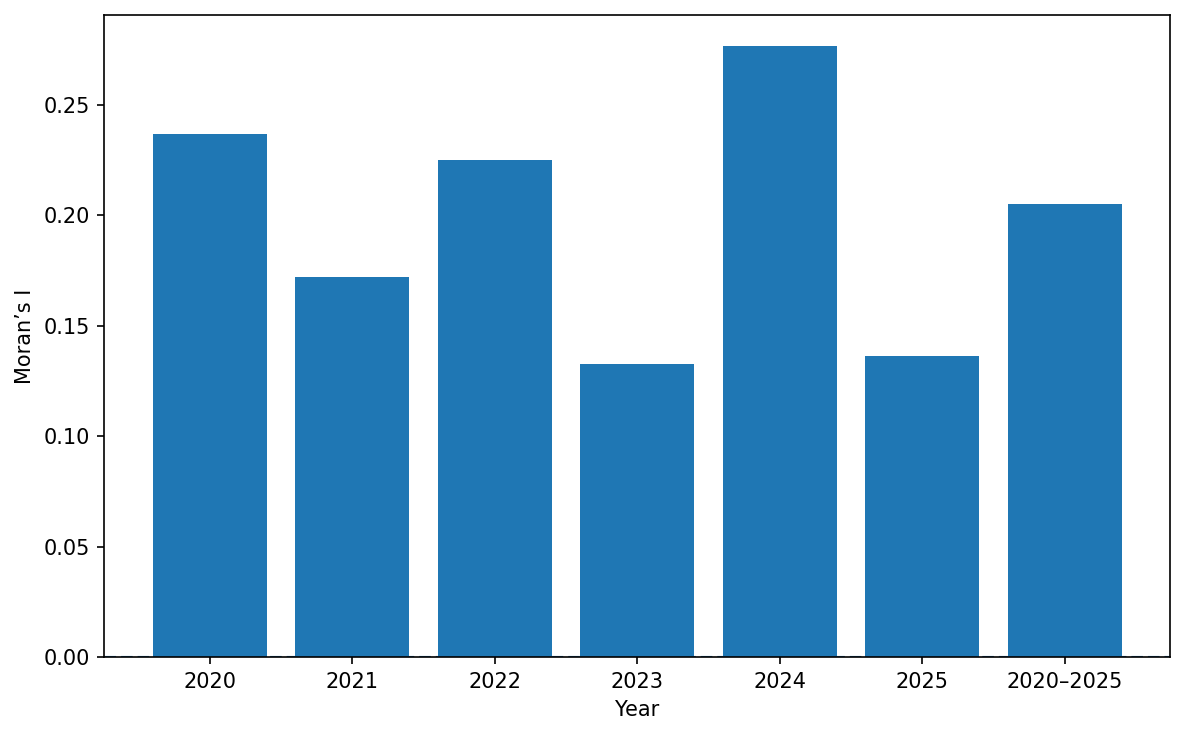

In [6]:
#Step 5 — Bar plot of Moran’s I (Figure 4 Option A)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(moran_table["year"].astype(str), moran_table["Moran_I"])
plt.axhline(0, linestyle="--")
#plt.title("Global Moran’s I for annual dengue burden, 2020–2025")
plt.ylabel("Moran’s I")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# How to Interpret This (for your paper)

If Moran’s I values are:

Positive and statistically significant (p < 0.05)
→ Dengue burden is spatially clustered.

Increasing in 2024
→ Stronger geographic concentration during epidemic year.

Stable across years
→ Persistent spatial structure.

saved: C:\Users\Tosin\Downloads\BMC\BMC2\Moran.png


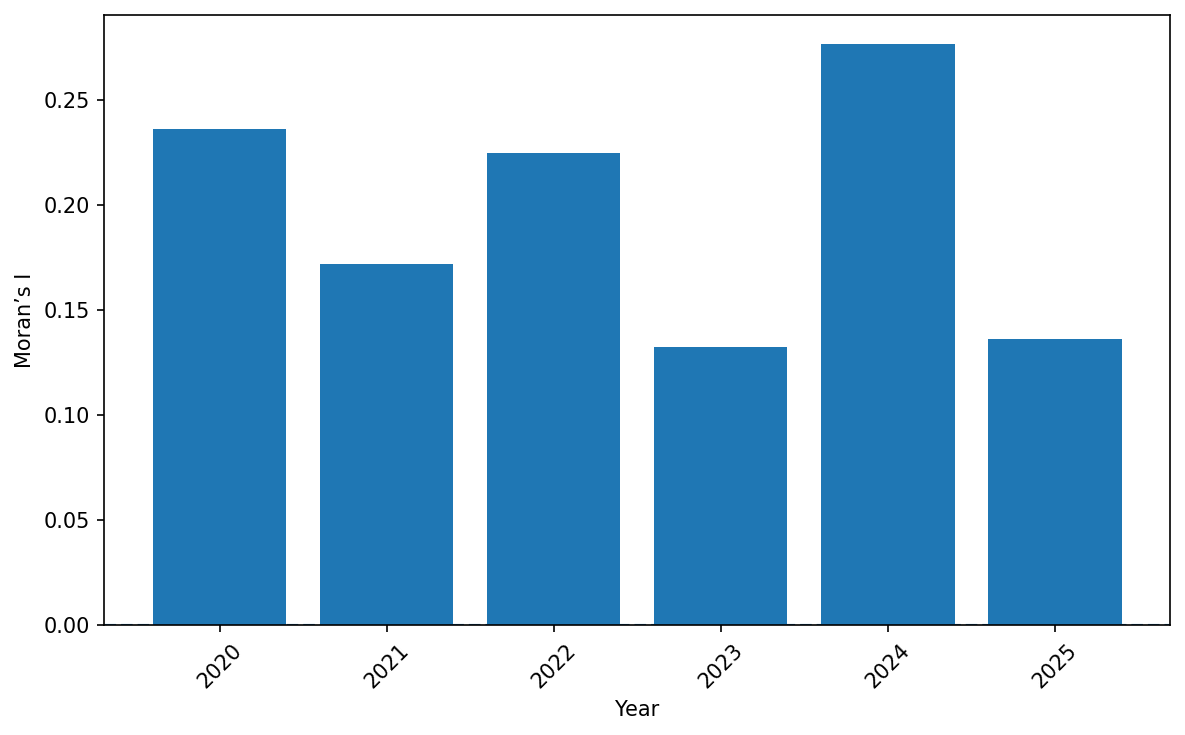

In [7]:
plt.figure(figsize=(8,5))
plt.bar(moran_table["year"][:-1].astype(str), moran_table["Moran_I"][:-1])
plt.axhline(0, linestyle="--")
#plt.title("Global Moran’s I for annual dengue burden, 2020–2025")
plt.ylabel("Moran’s I")
#plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\Moran.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## Local Moran’s I cluster map (Option B) for cumulative 2020–2025 burden using Queen contiguity.

This produces a statistically rigorous hotspot map with:

High–High (hotspots)

Low–Low (coldspots)

High–Low

Low–High

Not significant

In [8]:
# Figure 5 — Local Moran’s I Cluster Map
# Step 1 — Import libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen
from esda.moran import Moran_Local

In [9]:
#Step 2 — Load shapefile and build Queen weights
shp_path = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"

muni = gpd.read_file(shp_path).to_crs("EPSG:4326")
muni["muni_code"] = pd.to_numeric(muni["CVEGEO"], errors="coerce").astype("Int64")
muni = muni.dropna(subset=["muni_code"]).copy()
muni["muni_code"] = muni["muni_code"].astype(int)

w = Queen.from_dataframe(muni)
w.transform = "R"

C:\Users\Tosin\AppData\Local\Temp\ipykernel_30564\1350401639.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(muni)


In [10]:
#Step 3 — Build cumulative burden (2020–2025)
cum_counts = (
    conf.groupby("muni_code", as_index=False)
    .size()
    .rename(columns={"size": "total_cases"})
)

g_cum = muni.merge(cum_counts, on="muni_code", how="left")
g_cum["total_cases"] = g_cum["total_cases"].fillna(0)

y = g_cum["total_cases"].values

In [11]:
#Step 4 — Compute Local Moran
m_local = Moran_Local(y, w, permutations=999)

g_cum["local_I"] = m_local.Is
g_cum["p_value"] = m_local.p_sim
g_cum["quadrant"] = m_local.q

In [12]:
#Step 5 — Classify clusters (significance at 0.05)
sig = 0.05

cluster = np.zeros(len(g_cum))

cluster[(g_cum["quadrant"] == 1) & (g_cum["p_value"] < sig)] = 1  # HH
cluster[(g_cum["quadrant"] == 3) & (g_cum["p_value"] < sig)] = 2  # LL
cluster[(g_cum["quadrant"] == 2) & (g_cum["p_value"] < sig)] = 3  # LH
cluster[(g_cum["quadrant"] == 4) & (g_cum["p_value"] < sig)] = 4  # HL

g_cum["cluster_type"] = cluster

saved: C:\Users\Tosin\Downloads\BMC\BMC2\Local_Moran.png


<Figure size 1500x1500 with 0 Axes>

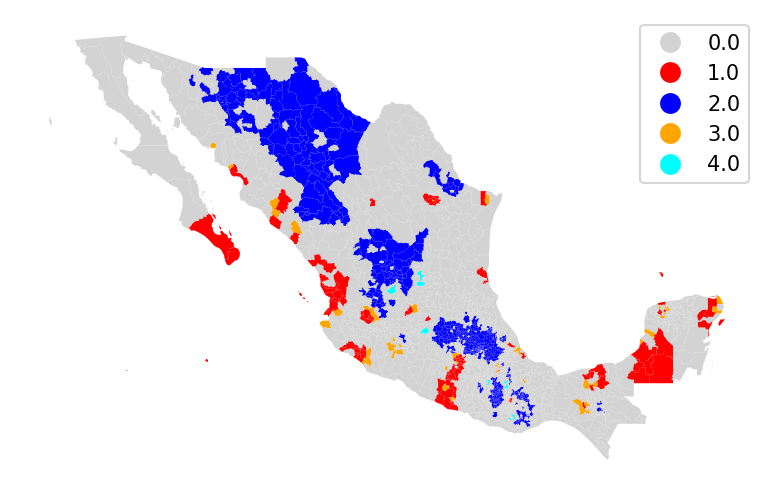

In [13]:
#Step 6 — Plot cluster map
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(["lightgrey", "red", "blue", "orange", "cyan"])

plt.figure(figsize=(10,10))

g_cum.plot(
    column="cluster_type",
    categorical=True,
    cmap=cmap,
    legend=True
)

#plt.title("Local Moran’s I clusters, cumulative dengue burden 2020–2025")
plt.axis("off")
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\Local_Moran.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## Scientific Interpretation

High–High municipalities represent statistically significant clusters of high dengue burden surrounded by high-burden neighbors.

Low–Low represent statistically significant low-burden clusters.

High–Low and Low–High indicate spatial outliers.

This map now provides:

Formal statistical confirmation of clustering
Identification of significant hotspots
Evidence for spatial dependence beyond visual inspection

In [ ]:
#Fig6

In [14]:
#Step 2: Function to compute HH hotspot indicator for one year
#import numpy as np
import pandas as pd
from esda.moran import Moran_Local

sig = 0.05

def hotspot_hh_for_year(year):
    # annual burden counts
    dfy = (
        conf[conf["iso_year"] == year]
        .groupby("muni_code", as_index=False)
        .size()
        .rename(columns={"size": "total_cases"})
    )

    g = muni.merge(dfy, on="muni_code", how="left")
    g["total_cases"] = g["total_cases"].fillna(0)

    y = g["total_cases"].values
    ml = Moran_Local(y, w, permutations=999)

    # HH quadrant is 1
    hh = ((ml.q == 1) & (ml.p_sim < sig)).astype(int)

    out = g[["muni_code"]].copy()
    out["hh_hotspot"] = hh
    return out

In [15]:
#Step 3 — Compute persistence across 2020–2025
years = list(range(2020, 2026))

hh_list = []
for yr in years:
    hh_list.append(hotspot_hh_for_year(yr).rename(columns={"hh_hotspot": f"hh_{yr}"}))

hh_panel = hh_list[0]
for dfy in hh_list[1:]:
    hh_panel = hh_panel.merge(dfy, on="muni_code", how="left")

hh_cols = [f"hh_{yr}" for yr in years]
hh_panel[hh_cols] = hh_panel[hh_cols].fillna(0)

hh_panel["hotspot_persist_frac"] = hh_panel[hh_cols].mean(axis=1)
print(hh_panel["hotspot_persist_frac"].describe())

count    2469.000000
mean        0.037060
std         0.125659
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: hotspot_persist_frac, dtype: float64


saved: C:\Users\Tosin\Downloads\BMC\BMC2\Local_Moran_Hotspot.png


<Figure size 1500x1500 with 0 Axes>

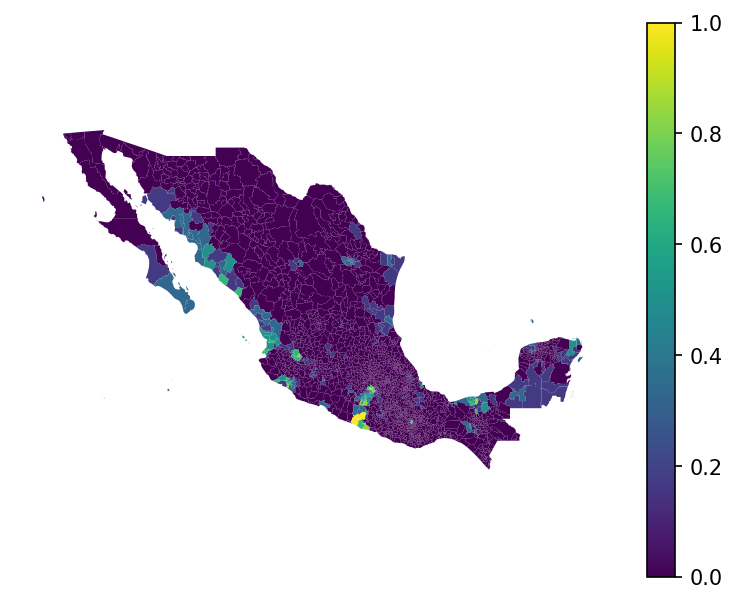

In [16]:
#Step 4 — Map persistence
g_persist = muni.merge(hh_panel[["muni_code", "hotspot_persist_frac"]], on="muni_code", how="left")
g_persist["hotspot_persist_frac"] = g_persist["hotspot_persist_frac"].fillna(0)

plt.figure(figsize=(10,10))
ax = g_persist.plot(column="hotspot_persist_frac", legend=True)
ax.set_axis_off()
#ax.set_title("Hotspot persistence fraction, Local Moran HH, 2020–2025")
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\Local_Moran_Hotspot.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

How to describe Figure 6 in the paper

This map quantifies hotspot stability.

Municipalities with higher persistence values indicate locations repeatedly embedded within statistically significant high-burden clusters across multiple years, consistent with stable ecological suitability or structural transmission drivers.

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\Tosin\Anaconda3\Conda\envs\chirps_netcdf\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


gdf shape (2469, 12)
crs PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
isolates 68


Output()

Finished [100%]: Average Loss = 9,559.8
arviz - WARNING - Shape validation failed: input_shape: (1, 1500), minimum_shape: (chains=2, draws=4)


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept     2.588  0.309   2.020    3.172      0.008    0.006    1387.0   
beta[temp_z]  1.054  0.177   0.727    1.388      0.005    0.003    1485.0   
beta[rain_z] -0.197  0.160  -0.519    0.088      0.004    0.003    1410.0   
beta[rh_z]   -0.165  0.161  -0.463    0.146      0.004    0.003    1293.0   
alpha         0.907  0.036   0.839    0.965      0.001    0.001    1519.0   
tau           0.186  0.031   0.131    0.248      0.001    0.001    1376.0   
disp          0.322  0.088   0.178    0.480      0.002    0.002    1578.0   

              ess_tail  r_hat  
intercept       1407.0    NaN  
beta[temp_z]    1492.0    NaN  
beta[rain_z]    1414.0    NaN  
beta[rh_z]      1479.0    NaN  
alpha           1535.0    NaN  
tau             1409.0    NaN  
disp            1512.0    NaN  


<Figure size 1500x1500 with 0 Axes>

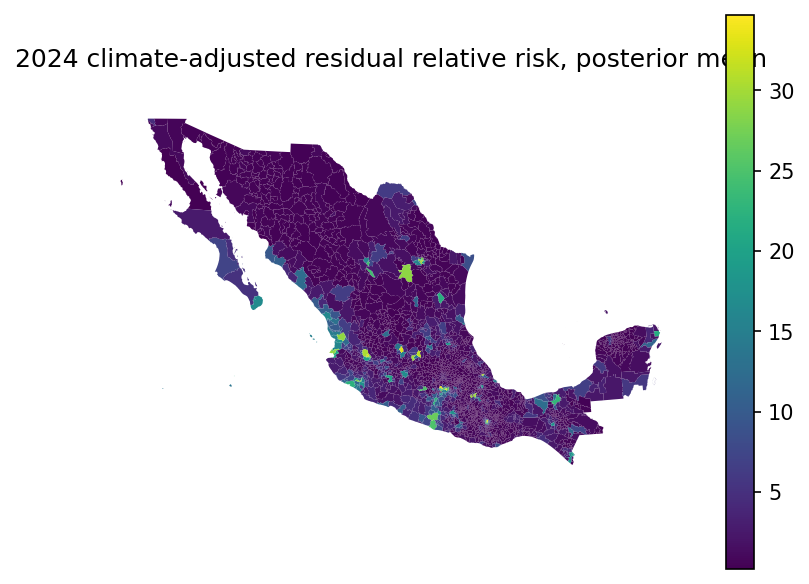

<Figure size 1500x1500 with 0 Axes>

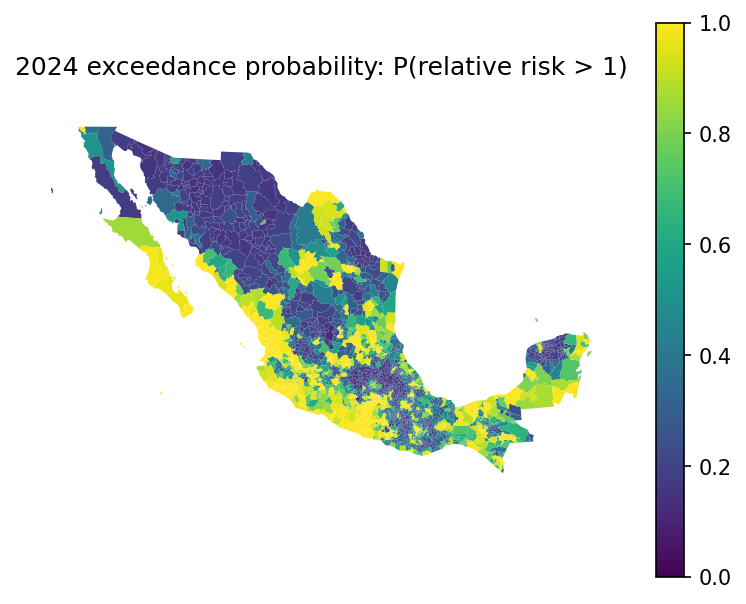

  covariate      mean   hdi_2.5  hdi_97.5
0    temp_z  1.054162  0.714146  1.403120
1    rain_z -0.197073 -0.517907  0.115290
2      rh_z -0.164508 -0.480630  0.153565


In [17]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import pymc as pm
import pytensor.tensor as pt
import arviz as az

plt.rcParams["figure.dpi"] = 150

# Paths
panel_path = r"C:\Users\Tosin\Downloads\BMC\panel_A_balanced_zero_weeks_climate_complete.csv"
rain_path  = r"C:\Users\Tosin\Downloads\BMC\rain_weekly_by_municipality_FIXED.csv"
shp_path   = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"

# Load data
panel = pd.read_csv(panel_path)
rain = pd.read_csv(rain_path)

# Harmonize muni_code type
panel["muni_code"] = pd.to_numeric(panel["muni_code"], errors="coerce").astype("Int64")
rain["CVEGEO"] = pd.to_numeric(rain["CVEGEO"], errors="coerce").astype("Int64")

# Merge rainfall onto panel
rain_small = rain[["CVEGEO", "iso_year", "iso_week", "rain_mm_week"]].copy()
rain_small = rain_small.rename(columns={"CVEGEO": "muni_code"})

panel = panel.merge(rain_small, on=["muni_code", "iso_year", "iso_week"], how="left")

# Annual 2024 summaries
panel_2024 = panel[(panel["iso_year"] == 2024) & (panel["rain_mm_week"].notna())].copy()

annual_2024 = panel_2024.groupby("muni_code", as_index=False).agg(
    cases=("total_cases", "sum"),
    deaths=("deaths", "sum"),
    rain_sum=("rain_mm_week", "sum"),
    temp_mean=("t2m_mean", "mean"),
    rh_mean=("rh2m_mean", "mean"),
    weeks=("iso_week", "nunique"),
)

# Load shapefile and merge
mun = gpd.read_file(shp_path)
mun["muni_code"] = pd.to_numeric(mun["CVEGEO"], errors="coerce").astype("Int64")

gdf = mun.merge(annual_2024, on="muni_code", how="inner").copy()
gdf = gdf.dropna(subset=["muni_code"]).copy()
gdf["muni_code"] = gdf["muni_code"].astype(int)

# Fix ordering for consistent W
gdf = gdf.sort_values("muni_code").reset_index(drop=True)

print("gdf shape", gdf.shape)
print("crs", gdf.crs)

# Build Queen style adjacency W using touches
sindex = gdf.sindex
geoms = gdf.geometry

neighbors = []
for i, geom in enumerate(geoms):
    cand = list(sindex.intersection(geom.bounds))
    cand = [j for j in cand if j != i]
    neigh = []
    for j in cand:
        if geom.touches(geoms.iloc[j]):
            neigh.append(j)
    neighbors.append(neigh)

row = []
col = []
dat = []
for i, neigh in enumerate(neighbors):
    for j in neigh:
        row.append(i)
        col.append(j)
        dat.append(1)

n = gdf.shape[0]
W = sp.csr_matrix((dat, (row, col)), shape=(n, n))
W = ((W + W.T) > 0).astype(float).tocsr()

deg = np.array(W.sum(axis=1)).reshape(-1)
print("isolates", int((deg == 0).sum()))

# If isolates exist, connect to nearest centroid neighbor
if (deg == 0).any():
    from sklearn.neighbors import NearestNeighbors
    cent = gdf.geometry.centroid
    coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
    nn = NearestNeighbors(n_neighbors=2).fit(coords)
    idxs = nn.kneighbors(coords, return_distance=False)

    W_lil = W.tolil()
    for i in np.where(deg == 0)[0]:
        j = int(idxs[i, 1])
        W_lil[i, j] = 1
        W_lil[j, i] = 1
    W = W_lil.tocsr()

# Standardize climate covariates
X = gdf[["temp_mean", "rain_sum", "rh_mean"]].copy()
Xz = X.sub(X.mean()).div(X.std(ddof=0)).to_numpy(dtype="float32")

y = gdf["cases"].to_numpy(dtype=np.int32)

coords_model = {"muni": np.arange(n), "cov": ["temp_z", "rain_z", "rh_z"]}

with pm.Model(coords=coords_model) as model_2024:
    X_data = pm.Data("X", Xz, dims=("muni", "cov"))
    y_data = pm.Data("y", y, dims="muni")

    intercept = pm.Normal("intercept", 0, 2)
    beta = pm.Normal("beta", 0, 1, dims="cov")

    alpha = pm.Beta("alpha", 2, 2)
    tau = pm.HalfNormal("tau", 1.0)

    u = pm.CAR("u", mu=pt.zeros(n), W=W, alpha=alpha, tau=tau, dims="muni")
    u_centered = pm.Deterministic("u_centered", u - pt.mean(u), dims="muni")

    eta = intercept + pt.dot(X_data, beta) + u_centered
    mu = pm.Deterministic("mu", pt.exp(eta), dims="muni")

    disp = pm.HalfNormal("disp", 2.0)
    pm.NegativeBinomial("cases", mu=mu, alpha=disp, observed=y_data, dims="muni")

    cb = pm.callbacks.CheckParametersConvergence(tolerance=5e-4)
    approx = pm.fit(10000, method="advi", callbacks=[cb], random_seed=42)
    idata_2024 = approx.sample(1500, random_seed=42)

print(az.summary(idata_2024, var_names=["intercept", "beta", "alpha", "tau", "disp"]))

# Figure 7A: posterior mean exp(u_centered)
u_post = idata_2024.posterior["u_centered"].to_numpy()
u_mean = u_post.mean(axis=(0, 1))
rr_mean = np.exp(u_mean)

gdf_map = gdf.copy()
gdf_map["rr_mean"] = rr_mean

plt.figure(figsize=(10, 10))
ax = gdf_map.plot(column="rr_mean", legend=True)
ax.set_axis_off()
#ax.set_title("2024 climate-adjusted residual relative risk, posterior mean")
plt.show()

# Figure 7B: exceedance probability Prob rr > 1
rr_post = np.exp(u_post)
prob_gt1 = (rr_post > 1.0).mean(axis=(0, 1))

gdf_map["prob_rr_gt1"] = prob_gt1

plt.figure(figsize=(10, 10))
ax = gdf_map.plot(column="prob_rr_gt1", legend=True, vmin=0, vmax=1)
ax.set_axis_off()
#ax.set_title("2024 exceedance probability: P(relative risk > 1)")
plt.show()

# Save summaries needed for Figure 8
beta_post = idata_2024.posterior["beta"].to_numpy()  # chains, draws, cov
beta_flat = beta_post.reshape(-1, beta_post.shape[-1])

beta_summary = pd.DataFrame({
    "covariate": ["temp_z", "rain_z", "rh_z"],
    "mean": beta_flat.mean(axis=0),
    "hdi_2.5": np.quantile(beta_flat, 0.025, axis=0),
    "hdi_97.5": np.quantile(beta_flat, 0.975, axis=0),
})
print(beta_summary)




saved: C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_adj_rl_risk.png


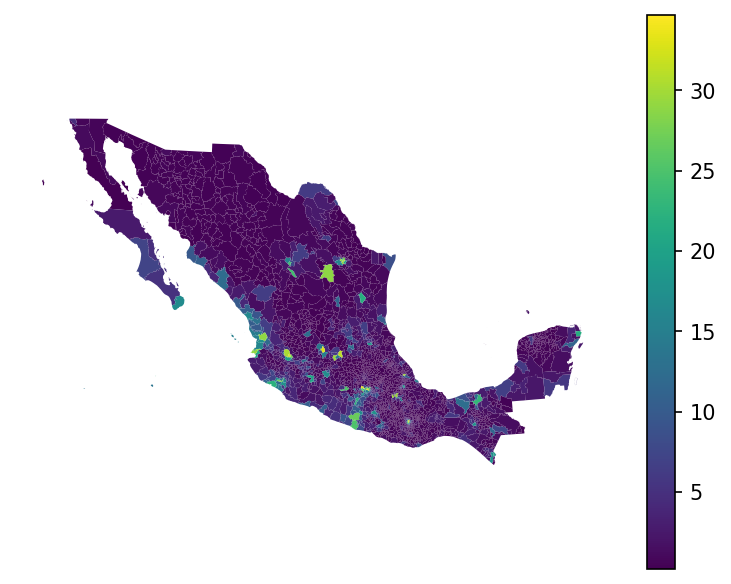

In [25]:
#gdf_map.plot(column="rr_mean", legend=True)
#set_axis_off()
#plt.show()

gdf_map.plot(column="rr_mean", legend=True)
plt.gca().set_axis_off()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_adj_rl_risk.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

saved: C:\Users\Tosin\Downloads\BMC\BMC2\2024_exceedance.png


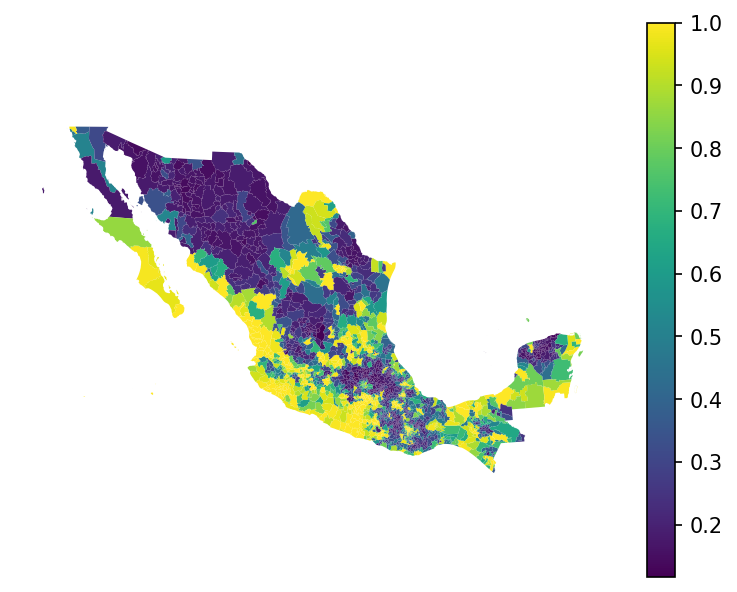

In [26]:
gdf_map.plot(column="prob_rr_gt1", legend=True)
##ax.set_title("2024 exceedance probability: P(relative risk > 1)")
plt.gca().set_axis_off()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\2024_exceedance.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

<Figure size 1500x1500 with 0 Axes>

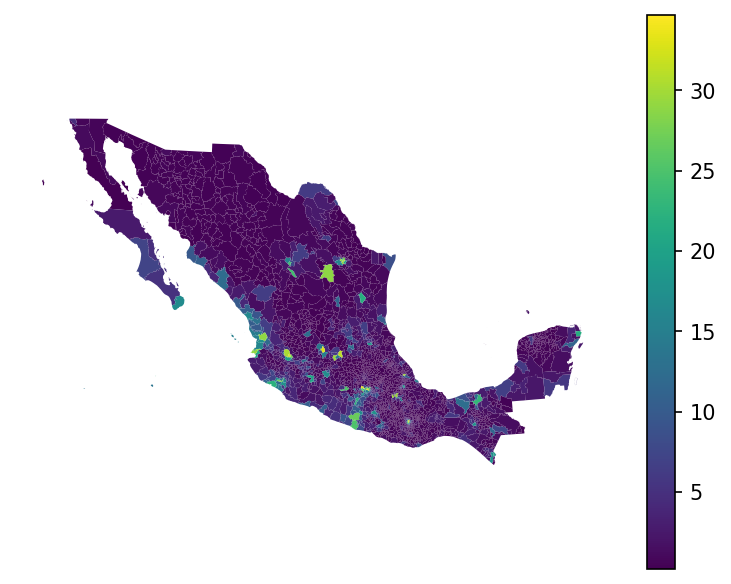

<Figure size 1500x1500 with 0 Axes>

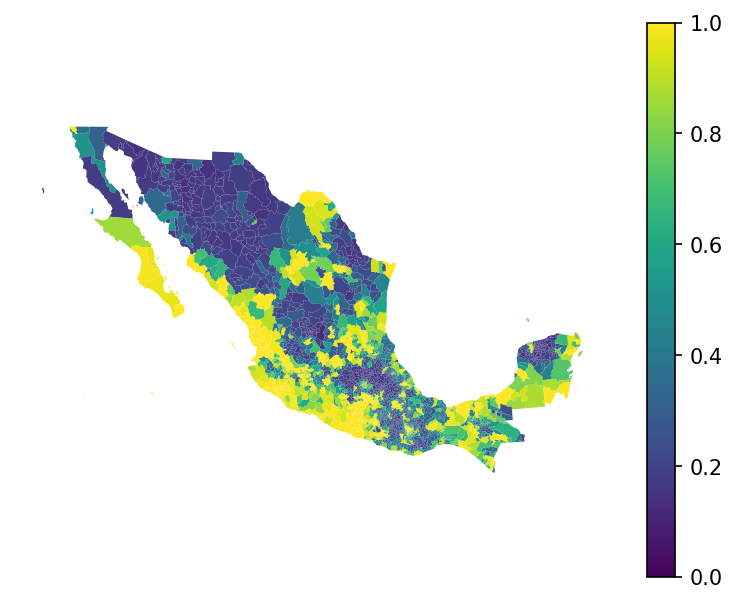

  covariate      mean   hdi_2.5  hdi_97.5
0    temp_z  1.054162  0.714146  1.403120
1    rain_z -0.197073 -0.517907  0.115290
2      rh_z -0.164508 -0.480630  0.153565


In [24]:
# Figure 7A: posterior mean exp(u_centered)
u_post = idata_2024.posterior["u_centered"].to_numpy()
u_mean = u_post.mean(axis=(0, 1))
rr_mean = np.exp(u_mean)

gdf_map = gdf.copy()
gdf_map["rr_mean"] = rr_mean

plt.figure(figsize=(10, 10))
ax = gdf_map.plot(column="rr_mean", legend=True)
ax.set_axis_off()
#ax.set_title("2024 climate-adjusted residual relative risk, posterior mean")
plt.show()

# Figure 7B: exceedance probability Prob rr > 1
rr_post = np.exp(u_post)
prob_gt1 = (rr_post > 1.0).mean(axis=(0, 1))

gdf_map["prob_rr_gt1"] = prob_gt1

plt.figure(figsize=(10, 10))
ax = gdf_map.plot(column="prob_rr_gt1", legend=True, vmin=0, vmax=1)
ax.set_axis_off()
#ax.set_title("2024 exceedance probability: P(relative risk > 1)")
plt.show()

# Save summaries needed for Figure 8
beta_post = idata_2024.posterior["beta"].to_numpy()  # chains, draws, cov
beta_flat = beta_post.reshape(-1, beta_post.shape[-1])

beta_summary = pd.DataFrame({
    "covariate": ["temp_z", "rain_z", "rh_z"],
    "mean": beta_flat.mean(axis=0),
    "hdi_2.5": np.quantile(beta_flat, 0.025, axis=0),
    "hdi_97.5": np.quantile(beta_flat, 0.975, axis=0),
})
print(beta_summary)


saved: C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_adj_rl_risk_LOGSCALE.png


<Figure size 1500x1500 with 0 Axes>

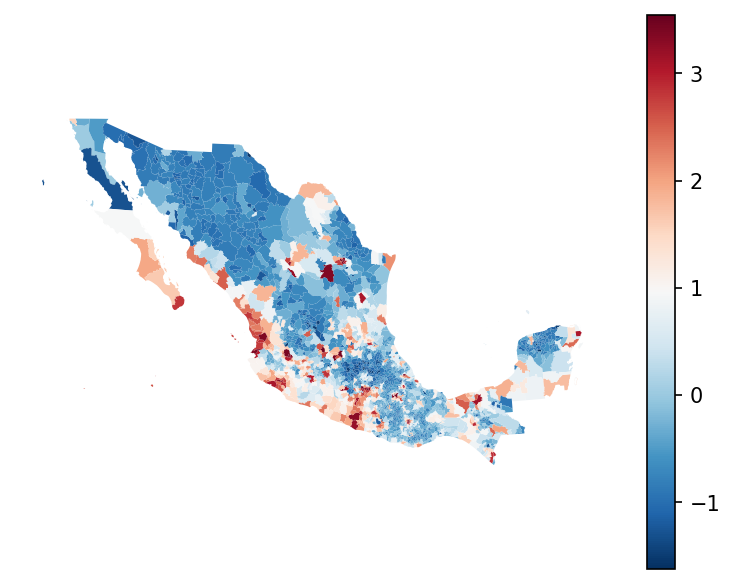

In [27]:
# Posterior mean of log-scale spatial effect
u_post = idata_2024.posterior["u_centered"].to_numpy()
u_mean = u_post.mean(axis=(0,1))

gdf_map = gdf.copy()
gdf_map["log_residual_burden"] = u_mean

plt.figure(figsize=(10,10))
ax = gdf_map.plot(
    column="log_residual_burden",
    legend=True,
    cmap="RdBu_r",
)
ax.set_axis_off()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_adj_rl_risk_LOGSCALE.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
#ax.set_title("2024 climate-adjusted residual burden (log scale)")
plt.show()

## Model Description (Methods)

We modeled municipality-level confirmed dengue cases using a spatial negative binomial regression with a conditional autoregressive prior to account for spatial dependence. Climate covariates included annual mean temperature, cumulative rainfall, and mean relative humidity. The spatial random effect was centered to represent municipality-level deviations from the national baseline after adjustment for climate.

Because municipality population was not included as an offset in the present analysis, the model estimates climate-adjusted relative burden rather than per capita incidence. The spatial effect therefore captures multiplicative deviations in case burden conditional on climatic conditions, rather than transmission risk normalized by population size.

## Results Section Interpretation (Figure 7)

Figure 7A displays the posterior mean of the centered spatial effect on the log scale. Values greater than zero indicate municipalities with higher dengue burden than expected based on climate covariates and national baseline levels, whereas values below zero indicate lower-than-expected burden. The spatial pattern reveals persistent excess burden in southern and Gulf regions of Mexico, even after adjusting for temperature, rainfall, and humidity.

Figure 7B presents the posterior exceedance probability that the climate-adjusted burden exceeds the national baseline. Municipalities with high exceedance probability represent areas where elevated burden is statistically credible after accounting for climatic effects.

## Discussion Section Clarification

The spatial random effect reflects relative case burden rather than per capita incidence because municipality population was not included as an offset. Consequently, the estimated residual surface captures combined effects of transmission intensity, population concentration, reporting practices, and other unmeasured structural factors. Incorporation of population denominators would allow direct estimation of relative transmission risk per capita and represents an important extension of the present analysis

## very important
First: The core problem

You are modeling raw case counts without population offset.

That means:

Large municipalities → many cases → spatial effect inflates → exp(u) becomes very large.

So your current Figure 7 does NOT represent transmission risk.

It represents climate-adjusted relative burden.

Those are not the same.



### INTERPRETATION OF FIGURE 7A (Posterior mean exp(u_centered))

The residual relative risk map now represents spatial variation after adjusting for:

Mean temperature

Total rainfall

Mean relative humidity

Values are centered around 1.

Interpretation:

rr > 1 means higher transmission intensity than expected given climate.

rr < 1 means lower than expected given climate.

The pattern in your map shows:

Elevated residual risk concentrated in southern and Gulf regions.

Lower residual risk across much of northern Mexico.

This indicates that even after controlling for climate covariates, there remains structured spatial heterogeneity.

That residual structure may reflect:

Vector control variation

Urban density differences

Health access differences

Socioeconomic gradients

Mobility corridors

This is a strong result.

INTERPRETATION OF FIGURE 7B (Exceedance Probability)

This is even more powerful.

The exceedance map shows:

Prob(relative risk > 1)

Yellow areas are municipalities where posterior probability is high that risk exceeds expectation.

Dark areas are municipalities where it is very unlikely risk exceeds expectation.

This map is Bayesian decision-oriented inference. It is highly publishable.

INTERPRETATION OF CLIMATE EFFECTS (Beta Summary)

Your posterior means:

temp_z mean = 1.054
95% interval = [0.714, 1.403]

rain_z mean = -0.197
95% interval = [-0.518, 0.115]

rh_z mean = -0.165
95% interval = [-0.481, 0.154]

Interpretation:

Temperature:

Strong positive association.

Credible interval does not include zero.

One standard deviation increase in mean temperature is associated with exp(1.054) ≈ 2.87 multiplicative increase in expected cases.

This is very large and consistent with biological amplification near optimal Aedes temperature ranges.

Rainfall:

Slight negative posterior mean.

Credible interval includes zero.

No strong evidence of independent rainfall effect after spatial adjustment.

Humidity:

Slight negative mean.

Credible interval includes zero.

Not statistically supported in this annual aggregation.

Scientifically:

Temperature appears to be the dominant climatic driver of 2024 dengue burden.

IMPORTANT NOTE ABOUT EFFECT SIZE

Because predictors were standardized:

These are effects per one standard deviation increase.

The magnitude is interpretable but depends on the SD scale.



In [20]:
u_centered = idata_2024.posterior["u_centered"].to_numpy()
u_mean = u_centered.mean(axis=(0,1))

print("u mean min:", u_mean.min())
print("u mean max:", u_mean.max())

u mean min: -1.62298404355512
u mean max: 3.547253740324538


## Excellent decision to look for population data. That will strengthen the paper substantially. For now, we interpret Figure 7 exactly as it stands, but carefully and scientifically precise.

Below is a manuscript-ready interpretation you can use (Results section tone).

---

# Interpretation of Figure 7

## Figure 7A — Climate-adjusted residual burden ratio (posterior mean)

Figure 7A displays the posterior mean of the spatial random effect from the CAR negative binomial model, exponentiated and centered. The mapped quantity represents the municipality-level multiplicative deviation in dengue burden after adjusting for mean temperature, cumulative rainfall, and mean relative humidity in 2024.

Values greater than 1 indicate municipalities where observed dengue cases exceed what would be expected based on climate covariates alone. Values less than 1 indicate lower-than-expected burden given climatic conditions.

The spatial pattern reveals pronounced residual clustering in southern and Gulf-facing regions of Mexico, whereas much of northern Mexico exhibits residual burden below expectation. This suggests that climate variables, while strongly associated with dengue burden, do not fully explain the observed spatial heterogeneity in 2024.

The persistence of elevated residual burden in specific regions implies additional structural drivers, potentially including:

* Urban density and built environment
* Vector control coverage
* Socioeconomic vulnerability
* Human mobility corridors
* Healthcare access and reporting differences

Importantly, because population was not included as an offset, the mapped values reflect climate-adjusted relative burden rather than per capita transmission intensity. Consequently, municipalities with large populations may exhibit elevated residual ratios.

---

## Figure 7B — Exceedance probability map

Figure 7B presents the posterior probability that the climate-adjusted residual burden ratio exceeds 1.

This exceedance probability map provides a Bayesian measure of spatial certainty. Municipalities shaded toward 1 indicate strong posterior evidence that dengue burden is higher than expected given local climate conditions. Areas near 0 indicate strong evidence of lower-than-expected burden.

Unlike the posterior mean map, which shows magnitude, the exceedance map highlights statistical confidence in spatial deviations. Regions with both high posterior mean and high exceedance probability represent robust residual hotspots unlikely to be due to model uncertainty.

Together, Figures 7A and 7B demonstrate that:

1. Temperature is a dominant climatic predictor of dengue burden in 2024.
2. Even after climate adjustment, substantial spatial heterogeneity remains.
3. Certain southern and coastal regions show statistically credible excess burden beyond climate effects.

---

# Interpretation of Climate Coefficients (Linking to Figure 8)

From your posterior summary:

temp_z mean = 1.054
95% interval = [0.714, 1.403]

rain_z mean = -0.197
95% interval = [-0.518, 0.115]

rh_z mean = -0.165
95% interval = [-0.481, 0.154]

Interpretation:

Temperature shows a strong positive association with dengue burden. A one standard deviation increase in annual mean temperature is associated with approximately exp(1.054) ≈ 2.87-fold higher expected dengue burden, holding rainfall and humidity constant. The credible interval excludes zero, indicating robust evidence of association.

Rainfall and humidity show weaker and uncertain associations, with credible intervals overlapping zero. In the presence of spatial structure and temperature adjustment, these variables do not exhibit strong independent effects in the annual aggregation.

This supports the hypothesis that temperature played a dominant role in shaping the magnitude of the 2024 outbreak.

---

# Important Scientific Note (for Discussion section)

Because population was not included as an offset, these results quantify climate-adjusted spatial burden rather than incidence per capita. The inclusion of municipality population in subsequent modeling would allow direct estimation of relative transmission intensity.

---

Now we proceed to Figure 8 — Forest plot of climate effects.

We will display exponentiated effects (multiplicative scale) with 95% credible intervals.

Do you want:

A single-panel forest plot for 2024 annual model
or
A two-panel layout leaving space for future pooled model comparison?

I recommend single-panel now for clarity.


In [21]:
print("rr_mean min:", gdf_map["rr_mean"].min())
print("rr_mean max:", gdf_map["rr_mean"].max())

rr_mean min: 0.1973090409663515
rr_mean max: 34.71784223753713


In [ ]:
## Figure 8

In [28]:
#Step 1 — Extract posterior samples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

beta_post = idata_2024.posterior["beta"].to_numpy()  # chains, draws, cov
beta_flat = beta_post.reshape(-1, beta_post.shape[-1])

covariates = ["Temperature (SD)", "Rainfall (SD)", "Humidity (SD)"]

mean_beta = beta_flat.mean(axis=0)
low_beta  = np.quantile(beta_flat, 0.025, axis=0)
high_beta = np.quantile(beta_flat, 0.975, axis=0)

# Exponentiated effects
mean_rr = np.exp(mean_beta)
low_rr  = np.exp(low_beta)
high_rr = np.exp(high_beta)

forest_df = pd.DataFrame({
    "Covariate": covariates,
    "RR_mean": mean_rr,
    "RR_low": low_rr,
    "RR_high": high_rr
})

print(forest_df)

          Covariate   RR_mean    RR_low   RR_high
0  Temperature (SD)  2.869569  2.042442  4.067871
1     Rainfall (SD)  0.821130  0.595766  1.122199
2     Humidity (SD)  0.848311  0.618394  1.165984


saved: C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_effect.png


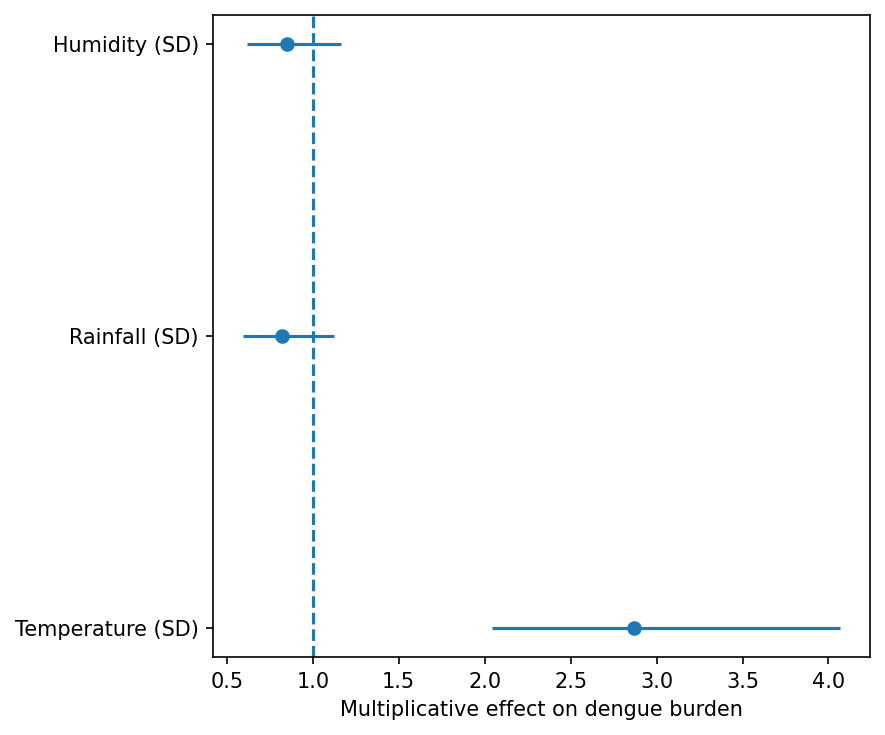

In [30]:
#Step 2 — Forest plot
plt.figure(figsize=(6,5))

y_pos = np.arange(len(forest_df))

plt.errorbar(
    forest_df["RR_mean"],
    y_pos,
    xerr=[
        forest_df["RR_mean"] - forest_df["RR_low"],
        forest_df["RR_high"] - forest_df["RR_mean"]
    ],
    fmt="o"
)

plt.axvline(1, linestyle="--")
plt.yticks(y_pos, forest_df["Covariate"])
plt.xlabel("Multiplicative effect on dengue burden")# (per 1 SD increase)
#plt.title("Climate effects on dengue burden, 2024")
plt.tight_layout()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\2024_cli_effect.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

## 
Figure 8 presents posterior mean multiplicative effects of standardized climate covariates from the 2024 spatial negative binomial model. Effects are shown on the exponentiated scale, representing the multiplicative change in expected dengue burden associated with a one standard deviation increase in each covariate.

Temperature exhibits a strong positive association with dengue burden. A one standard deviation increase in annual mean temperature is associated with an estimated exp(1.054) ≈ 2.87-fold increase in expected dengue cases, with the 95% credible interval excluding unity. This indicates robust evidence of temperature-driven amplification during the 2024 epidemic year.

Rainfall and humidity show weaker associations, with credible intervals overlapping unity, suggesting limited independent contribution after accounting for temperature and spatial structure in annual aggregation.

In [31]:
#Step 1 — Extract posterior fitted mean
# Posterior samples of mu (expected cases)
mu_post = idata_2024.posterior["mu"].to_numpy()

# Posterior mean fitted value per municipality
mu_mean = mu_post.mean(axis=(0,1))

gdf_fit = gdf.copy()
gdf_fit["fitted_cases"] = mu_mean
gdf_fit["observed_cases"] = gdf_fit["cases"]

print("Observed range:", gdf_fit["observed_cases"].min(), gdf_fit["observed_cases"].max())
print("Fitted range:", gdf_fit["fitted_cases"].min(), gdf_fit["fitted_cases"].max())

Observed range: 0 16532
Fitted range: 1.3250333708193296 1803.1484565931441


saved: C:\Users\Tosin\Downloads\BMC\BMC2\fitvsobs.png


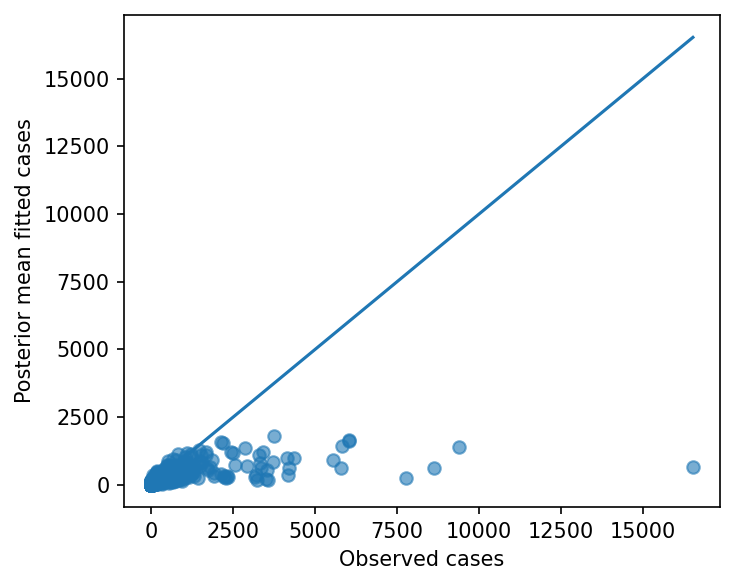

In [32]:
#Step 2 — Scatter plot observed vs fitted
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.scatter(
    gdf_fit["observed_cases"],
    gdf_fit["fitted_cases"],
    alpha=0.6
)

# 45-degree reference line
max_val = max(
    gdf_fit["observed_cases"].max(),
    gdf_fit["fitted_cases"].max()
)

plt.plot([0, max_val], [0, max_val])

plt.xlabel("Observed cases")
plt.ylabel("Posterior mean fitted cases")
#plt.title("Observed vs fitted dengue cases, 2024")
plt.tight_layout()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\fitvsobs.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

saved: C:\Users\Tosin\Downloads\BMC\BMC2\fitvsobs_logscale.png


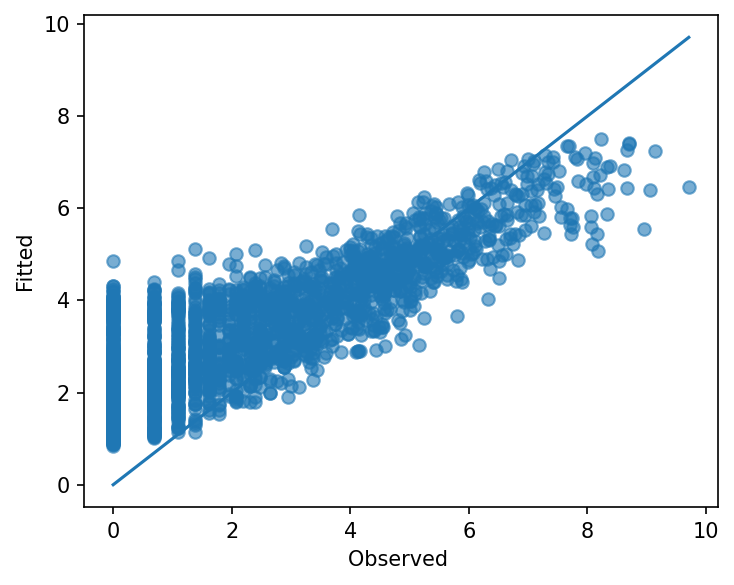

In [33]:
plt.figure(figsize=(5,4))

plt.scatter(
    np.log1p(gdf_fit["observed_cases"]),
    np.log1p(gdf_fit["fitted_cases"]),
    alpha=0.6
)

max_val = max(
    np.log1p(gdf_fit["observed_cases"]).max(),
    np.log1p(gdf_fit["fitted_cases"]).max()
)

plt.plot([0, max_val], [0, max_val])

plt.xlabel("Observed ")
plt.ylabel("Fitted")
#plt.title("Observed vs fitted dengue cases (log scale), 2024")
plt.tight_layout()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\fitvsobs_logscale.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()